<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/Android_Ransomware_Detection_Alamgir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection Detection**

## **Font family setup**

In [1]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link:

## **Importing Dataset**

In [2]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

## **Basic Information**

In [4]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [5]:
df.head()

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [6]:
df.shape

(392034, 79)

In [7]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


## **Data Samples per Class**

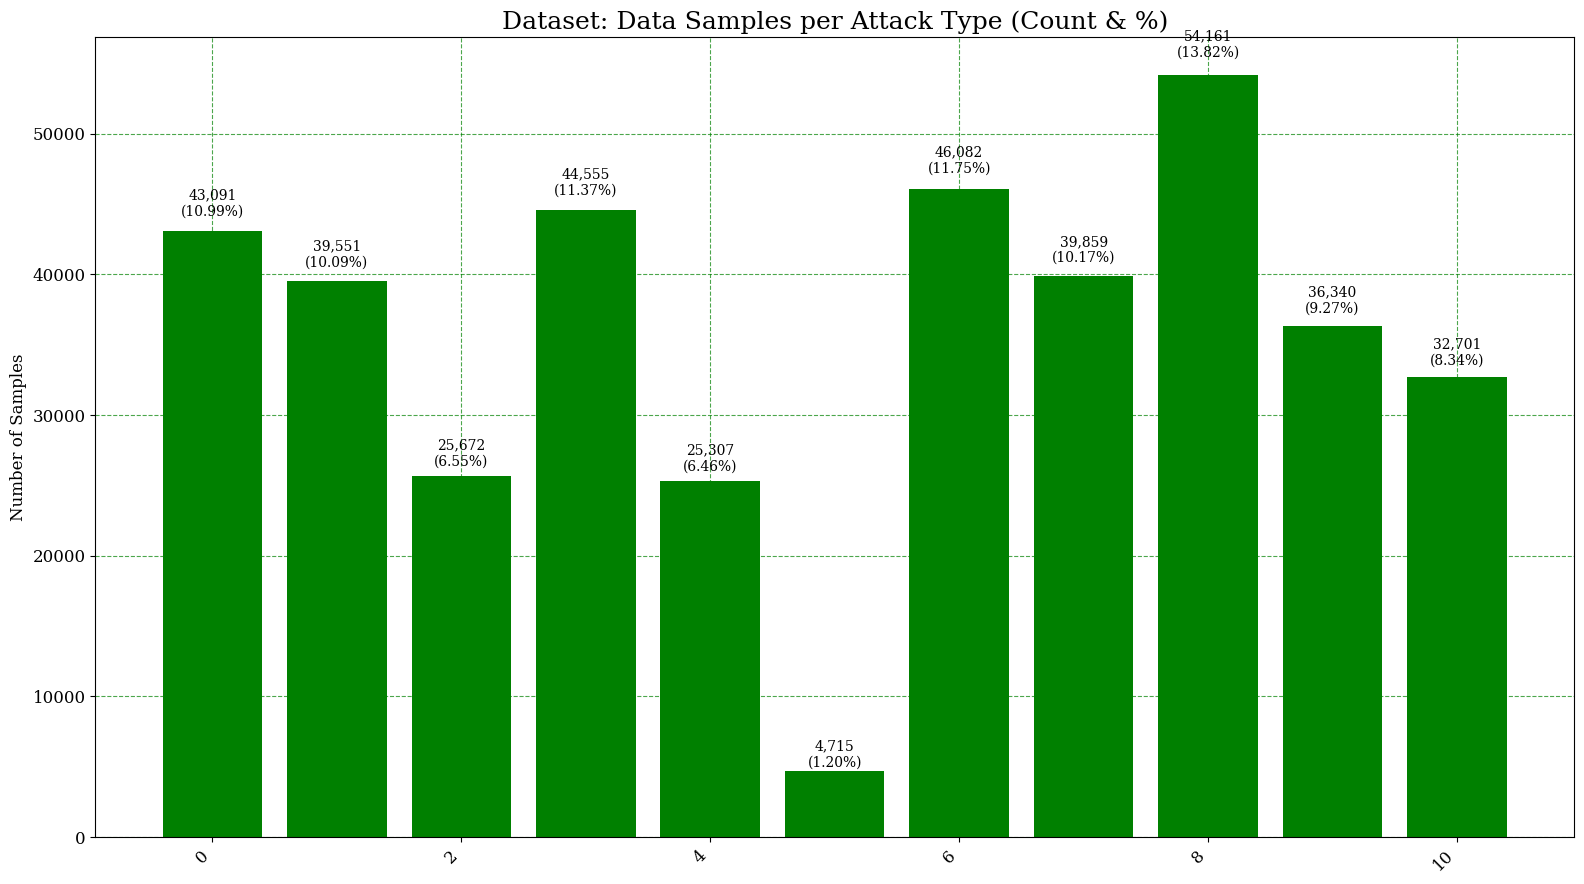

In [8]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [9]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
#df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Verify if missing values are filled
#print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled



Columns with Missing Values:
 Series([], dtype: int64)


In [10]:
# Print the names of the features (columns)
print(df.columns)

Index(['Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       

## **Data Preprocessing**

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ১. ইনফিনিটি এবং গারবেজ ভ্যালু ক্লিন করা
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)
df.dropna(inplace=True)

# ২. Numerical কলাম আলাদা করা (Label বাদ দিয়ে)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.difference(['Label'])

# ৩. ফিচার স্কেলিং (শুধু Numerical ফিচারে)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# ৪. Categorical কলাম আলাদা করা (Label বাদ দিয়ে)
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])

# ৫. Categorical এনকোডিং (সব কলাম স্ট্রিং নিশ্চিত করে)
df[cat_cols] = df[cat_cols].astype(str)
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)



print("Preprocessing Success!")
print(df['Label'].value_counts()) # চেক করুন শুধু ০ এবং ১ আছে কি না


Preprocessing Success!
Label
1    348943
0     43091
Name: count, dtype: int64


## **After Processing**

In [14]:
df['Label'].value_counts()

,count
Label,
1,348943
0,43091


In [15]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()

# **Binary Class (Anomaly) Classification**

In [16]:
# বাইনারি ক্লাসিফিকেশনের জন্য লেবেল রূপান্তর (যদি ০ Benign হয়)
# এটি করলে আপনার ১১টি ক্লাস ০ এবং ১ এ চলে আসবে
df['Label'] = df['Label'].apply(lambda x: 0 if x == 0 else 1)

# Define label and feature columns
X = df1.drop(columns=['Label'])
y = df1['Label']

## **Traing and Test Division**

In [17]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 78)
X_test shape:  (78407, 78)
y_train shape: (313627,)
y_test shape:  (78407,)


Feature selection

In [18]:
import lightgbm as lgb
import pandas as pd
import numpy as np

# ১. লেবেলগুলোকে অবশ্যই পূর্ণসংখ্যা (Integer) হতে হবে
# আপনার লেবেলে যদি -১.৫৪ টাইপ ভ্যালু থাকে, সেগুলোকে ০ এবং ১-এ বদলে নিন
y_train_int = y_train.astype(int)

# ২. LightGBM মডেল (ইমব্যালেন্স ডাটা হ্যান্ডেল করার জন্য)
lgbm_selector = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True, # আপনার Ransomware ডাটা অনেক বেশি, তাই এটি জরুরি
    random_state=42,
    verbose=-1
)

# ৩. ট্রেইন করা
lgbm_selector.fit(X_train, y_train_int)

# ৪. এখন ইম্পর্ট্যান্স চেক করুন (এখন আর ০ আসবে না)
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

# ৫. সেরা ৪০টি ফিচারের নাম নেওয়া
top_40_features = importance_df.head(40)['Feature'].tolist()

print("Top 10 Features (Corrected):")
print(importance_df.head(40))


Top 10 Features (Corrected):
                        Feature  Importance
67      Init_Win_bytes_backward         296
66       Init_Win_bytes_forward         266
20                 Flow IAT Min         150
0              Destination Port         118
42            Packet Length Std         109
25                  Fwd IAT Min         104
19                 Flow IAT Max         101
40            Max Packet Length          90
5   Total Length of Fwd Packets          81
30                  Bwd IAT Min          80
12        Bwd Packet Length Min          78
69         min_seg_size_forward          75
37                Fwd Packets/s          74
7         Fwd Packet Length Max          70
14        Bwd Packet Length Std          70
39            Min Packet Length          64
2                 Flow Duration          63
15                 Flow Bytes/s          62
11        Bwd Packet Length Max          57
21                Fwd IAT Total          54
8         Fwd Packet Length Min          54
36 

/tmp/ipykernel_18850/2876996300.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(40), palette='viridis')


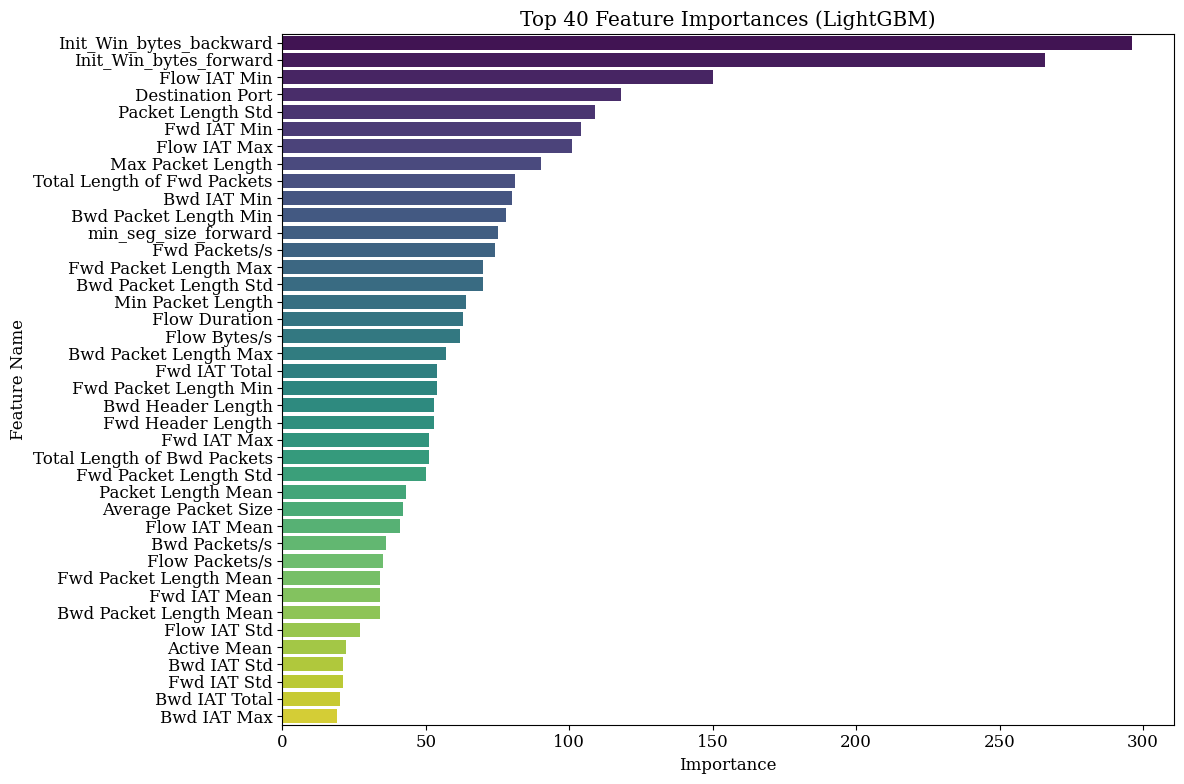

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(40), palette='viridis')
plt.title('Top 40 Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.8857
Precision: 0.8866
Recall:    0.8857
F1 Score:  0.8862


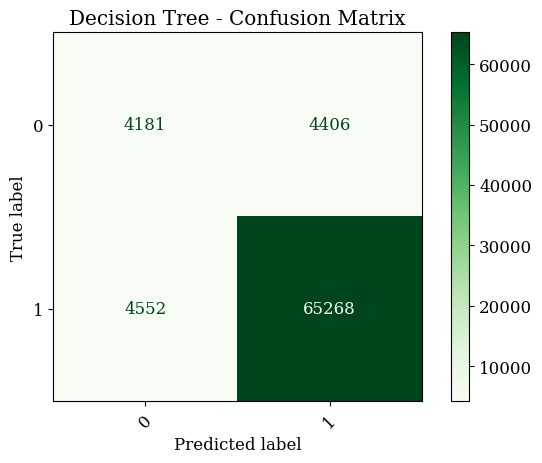

Classification Report:
              precision    recall  f1-score   support

           0    0.47876   0.48690   0.48279      8587
           1    0.93676   0.93480   0.93578     69820

    accuracy                        0.88575     78407
   macro avg    0.70776   0.71085   0.70929     78407
weighted avg    0.88660   0.88575   0.88617     78407



In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
X_train = X_train[top_40_features]
X_test = X_test[top_40_features]


# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

In [28]:
print(X_train)


        Init_Win_bytes_backward  Init_Win_bytes_forward  Flow IAT Min  \
337826                -0.219727                1.377421     -0.230794   
102738                -0.233949               -0.756128     -0.230606   
354191                -0.233949               -0.756128     -0.217896   
306294                -0.116940                1.377421     -0.230794   
173169                -0.233949               -0.710973     -0.206807   
...                         ...                     ...           ...   
259178                -0.200881                1.377421     -0.230794   
365838                -0.233949               -0.756128     -0.121148   
131932                 7.343420                1.377421     -0.229784   
146867                -0.233949               -0.752091     -0.230792   
121958                -0.230249               -0.756095     -0.183637   

        Destination Port  Packet Length Std  Fwd IAT Min  Flow IAT Max  \
337826         -0.358896           0.435271    -0

## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.91497
Precision: 0.90396
Recall:    0.91497
F1 Score:  0.90435


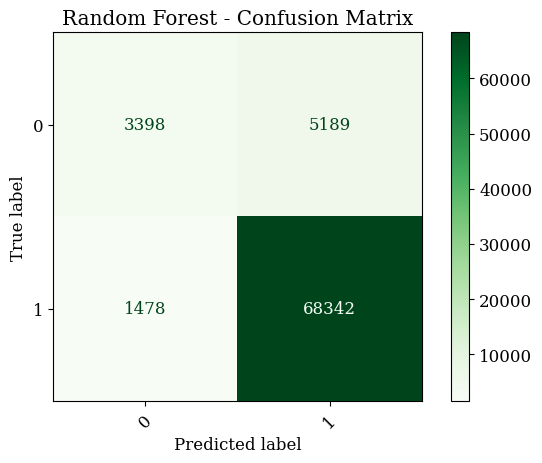

Classification Report:
              precision    recall  f1-score   support

           0    0.69688   0.39571   0.50479      8587
           1    0.92943   0.97883   0.95349     69820

    accuracy                        0.91497     78407
   macro avg    0.81316   0.68727   0.72914     78407
weighted avg    0.90396   0.91497   0.90435     78407



In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.89319
Precision: 0.87703
Recall:    0.89319
F1 Score:  0.88235


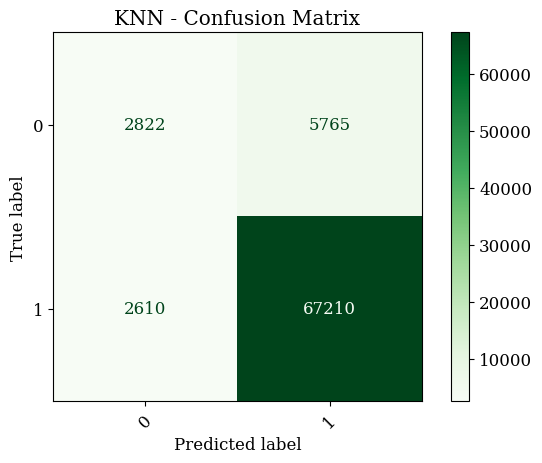

Classification Report:
              precision    recall  f1-score   support

           0    0.51951   0.32864   0.40260      8587
           1    0.92100   0.96262   0.94135     69820

    accuracy                        0.89319     78407
   macro avg    0.72026   0.64563   0.67197     78407
weighted avg    0.87703   0.89319   0.88235     78407



In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=3)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Training Stacked Classifier...
Stacked Classifier training complete.

Stacked Classifier Accuracy:  0.91693
Stacked Classifier Precision: 0.90672
Stacked Classifier Recall:    0.91693
Stacked Classifier F1 Score:  0.90454


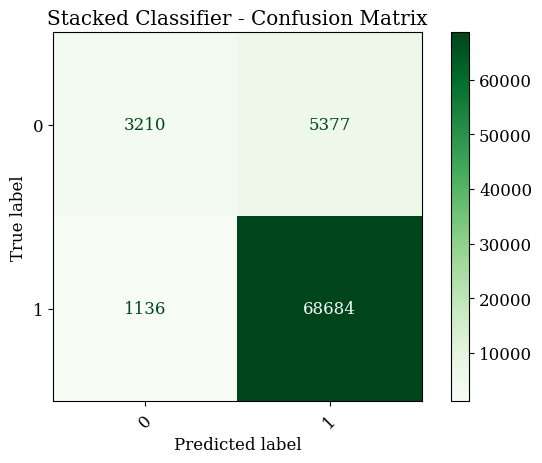

Stacked Classifier Classification Report:
              precision    recall  f1-score   support

           0    0.73861   0.37382   0.49640      8587
           1    0.92740   0.98373   0.95473     69820

    accuracy                        0.91693     78407
   macro avg    0.83300   0.67878   0.72557     78407
weighted avg    0.90672   0.91693   0.90454     78407



In [31]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Define Base Estimators
dt_base = DecisionTreeClassifier(random_state=42)
rf_base = RandomForestClassifier(n_estimators=50, random_state=42)
knn_base = KNeighborsClassifier(n_neighbors=3) # Using n_neighbors=3 as in previous KNN binary classification

estimators = [
    ('dt', dt_base),
    ('rf', rf_base),
    ('knn', knn_base)
]

# 2. Define Meta-Estimator
# A simple classifier like LogisticRegression is often used for the meta-learner
meta_estimator = LogisticRegression(solver='liblinear', random_state=42)

# 3. Create the Stacking Classifier
stacked_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_estimator,
    cv=5, # Number of cross-validation folds for base estimators
    stack_method='auto', # 'auto' selects 'predict_proba' if available, otherwise 'predict'
    n_jobs=-1, # Use all available CPU cores
    passthrough=True # Pass original features to the final estimator
)

print("Training Stacked Classifier...")
# 4. Train the Stacked Classifier
stacked_clf.fit(X_train, y_train)
print("Stacked Classifier training complete.")

# 5. Predict on Test Set
y_pred_stacked = stacked_clf.predict(X_test)

# 6. Evaluation Metrics
accuracy_stacked = accuracy_score(y_test, y_pred_stacked)
precision_stacked = precision_score(y_test, y_pred_stacked, average='weighted', zero_division=0)
recall_stacked = recall_score(y_test, y_pred_stacked, average='weighted', zero_division=0)
f1_stacked = f1_score(y_test, y_pred_stacked, average='weighted', zero_division=0)

# 7. Print Basic Metrics (5-digit precision)
print(f"\nStacked Classifier Accuracy:  {accuracy_stacked:.5f}")
print(f"Stacked Classifier Precision: {precision_stacked:.5f}")
print(f"Stacked Classifier Recall:    {recall_stacked:.5f}")
print(f"Stacked Classifier F1 Score:  {f1_stacked:.5f}")

# Confusion Matrix
cm_stacked = confusion_matrix(y_test, y_pred_stacked)
ConfusionMatrixDisplay(cm_stacked, display_labels=stacked_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Stacked Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Stacked Classifier Classification Report:")
print(classification_report(y_test, y_pred_stacked, zero_division=0, digits=5))


# **Multiclass Classification**

In [ ]:
# Define label and feature columns
X = df2.drop(columns=['Label'])
y = df2['Label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 84)
X_test shape:  (78407, 84)
y_train shape: (313627,)
y_test shape:  (78407,)


## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.9973
Precision: 0.9973
Recall:    0.9973
F1 Score:  0.9973


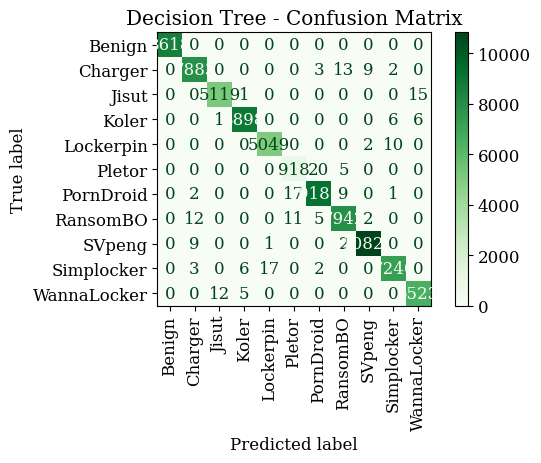

Classification Report:
              precision    recall  f1-score   support

      Benign    1.00000   1.00000   1.00000      8618
     Charger    0.99671   0.99659   0.99665      7910
       Jisut    0.99747   0.99688   0.99718      5135
       Koler    0.99865   0.99854   0.99860      8911
   Lockerpin    0.99645   0.99763   0.99704      5061
      Pletor    0.97040   0.97349   0.97194       943
   PornDroid    0.99675   0.99685   0.99680      9217
    RansomBO    0.99636   0.99624   0.99630      7972
      SVpeng    0.99880   0.99889   0.99885     10832
  Simplocker    0.99738   0.99615   0.99676      7268
 WannaLocker    0.99679   0.99740   0.99710      6540

    accuracy                        0.99733     78407
   macro avg    0.99507   0.99533   0.99520     78407
weighted avg    0.99734   0.99733   0.99733     78407



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.95203
Precision: 0.95208
Recall:    0.95203
F1 Score:  0.95168


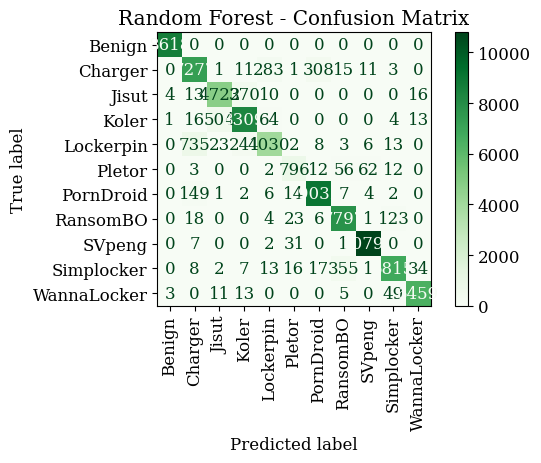

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99907   1.00000   0.99954      8618
     Charger    0.88463   0.91997   0.90196      7910
       Jisut    0.89704   0.91957   0.90816      5135
       Koler    0.92807   0.93244   0.93025      8911
   Lockerpin    0.91300   0.79629   0.85066      5061
      Pletor    0.90147   0.84411   0.87185       943
   PornDroid    0.96259   0.97993   0.97118      9217
    RansomBO    0.94635   0.97805   0.96194      7972
      SVpeng    0.99218   0.99621   0.99420     10832
  Simplocker    0.97066   0.93767   0.95388      7268
 WannaLocker    0.99034   0.98761   0.98898      6540

    accuracy                        0.95203     78407
   macro avg    0.94413   0.93562   0.93933     78407
weighted avg    0.95208   0.95203   0.95168     78407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.96185
Precision: 0.96191
Recall:    0.96185
F1 Score:  0.96186


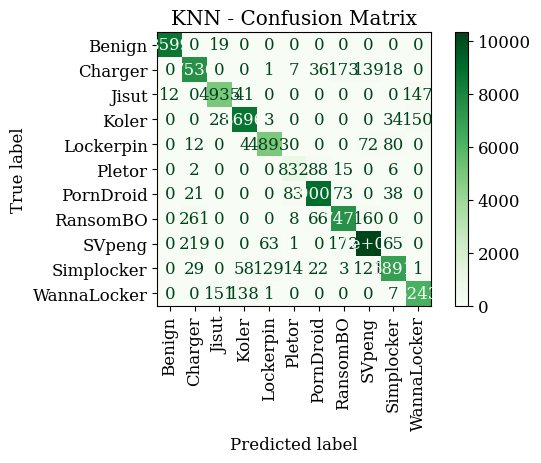

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99861   0.99780   0.99820      8618
     Charger    0.93267   0.95272   0.94259      7910
       Jisut    0.96143   0.96105   0.96124      5135
       Koler    0.97303   0.97587   0.97445      8911
   Lockerpin    0.96130   0.96680   0.96404      5061
      Pletor    0.88042   0.88229   0.88136       943
   PornDroid    0.97699   0.97667   0.97683      9217
    RansomBO    0.94490   0.93791   0.94139      7972
      SVpeng    0.95446   0.95199   0.95323     10832
  Simplocker    0.96526   0.94813   0.95662      7268
 WannaLocker    0.95444   0.95459   0.95451      6540

    accuracy                        0.96185     78407
   macro avg    0.95487   0.95507   0.95495     78407
weighted avg    0.96191   0.96185   0.96186     78407



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Modified Confusion Matrix**

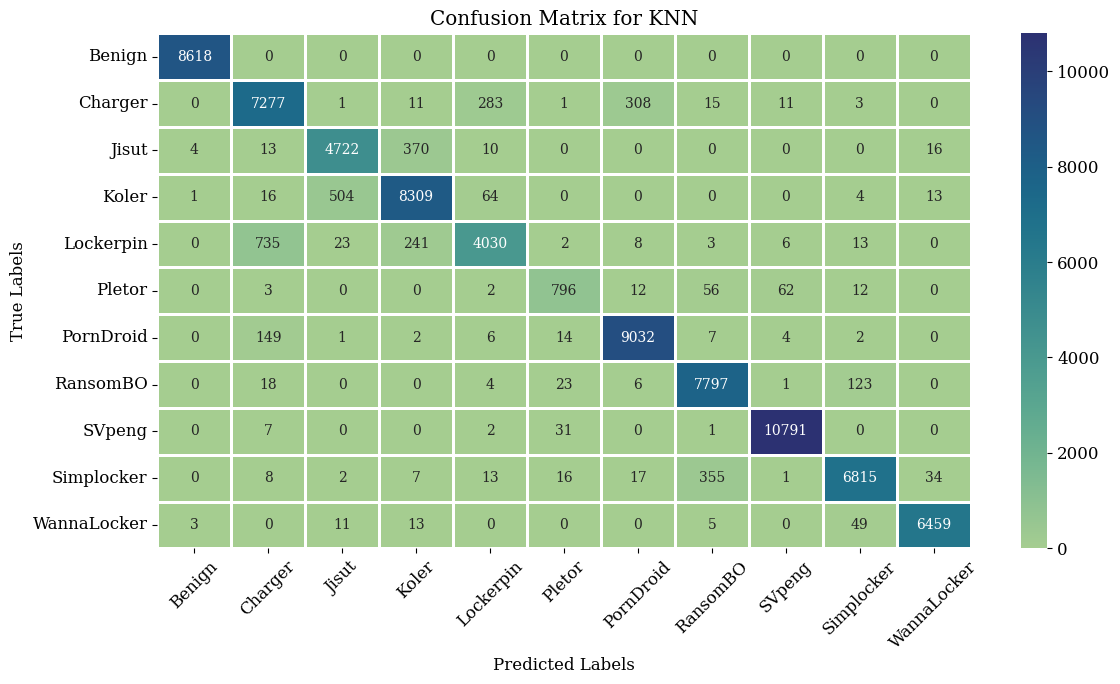

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**